In [5]:
import torch
import numpy as np

x = np.arange(0, 10)
tensor = torch.from_numpy(x)
print(tensor)
print(x)
numpy_array = torch.Tensor.numpy(tensor)
print(f"type: {type(numpy_array)}: {numpy_array}")

# numpy to tensor -> dtype is float64
# tensor to numpy -> dtype is float32
#  and they dont share memory...
 



tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
[0 1 2 3 4 5 6 7 8 9]
type: <class 'numpy.ndarray'>: [0 1 2 3 4 5 6 7 8 9]


In [6]:
# reproducibility....

torch.manual_seed(seed=50)
random_num = torch.rand(size=(3,2))
torch.manual_seed(seed=50)
random_num2 = torch.rand(size=(3,2))

random_num == random_num2

tensor([[True, True],
        [True, True],
        [True, True]])

In [7]:
# Getting a GPU

# 1. Easiest - Use Google Colab for a free GPU (options to upfrade as well)
# 2. Use your own GPU- takes a little bit of setup and requires the investment of purchasing a GPU, there's lots of options ... , see this post for
# what option to get: https://timdettmers.com/2020/09/07/which-gpu-for-deep-learning/
# 3. Use cloud computing - GCP, AWS, Azure, these services allow you to rent computers on the cloud and access them
# For 2, 3 PyTorch + GPU drivers (CUDA) takes a little bit of setting up, to do this, refer to PyTorch setup documentation: https://pytorch.org/get-started/locally/

In [8]:
torch.cuda.is_available()
# setup device agnostic code
device =  "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
device =  "cuda" if torch.cuda.is_available() else "cpu"
x = torch.tensor([1,5,6,6], device=device)
x
print(x.device)
x.to(device) #use to change to cpu to cuda and vice versa
# tensor on gpu cannot be convert to numpy
# using tensor.cpu().numpy()

cpu


tensor([1, 5, 6, 6])

In [10]:
# fundamental exercise...

import torch
import matplotlib.pyplot as plt

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02

X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
# print(X.unsqueeze(dim=1))
# print(X)

y = weight * X + bias
len(y)
len(X)







50

In [11]:

train_split = int(0.8 * len(X))
x_train, y_train = X[: train_split], y[: train_split]
x_test, y_test = X[train_split :], y[train_split :]

len(x_train), len(y_train), len(x_test), len(y_test)




(40, 40, 10, 10)

In [12]:
def plot_predictions(train_data=x_train, train_label=y_train, test_data=x_test, test_label=y_test, predictions=None):
    plt.scatter(train_data, train_label, c="b", s=4, label="Training Data...")
    plt.scatter(test_data, test_label, c="g", s=4, label="Testing Data...")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size" : 14})

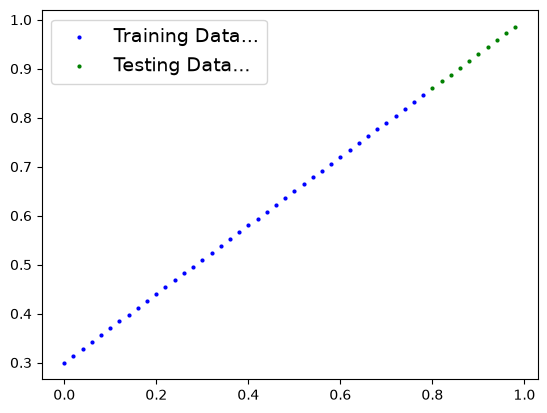

In [13]:
plot_predictions()

In [14]:
# pytorch model....

## 2. Build model

# Our first PyTorch model!

# This is very exciting ... let's do it!

# Because we're going to be building classes throughout the course,
# I'd recommend getting familiar with OOP in Python, to do so you can
# use the following

# 1 . Gradient descent - https://youtu.be/IHZwWFHWa-w
# 2. Backpropagation -https://youtu.be/llg3gGewQ5U

# * torch.nn - contains all of the buildings for computational graphs
# (a neural network can be considered a computational graph)
# * torch.nn.Parameter - what parameters should our model try and
# learn, often a PyTorch layer from torch.nn will set these for us
# * torch.nn.Module - The base cyass for all neural network modules,
# if you subclass it, you shouldfoverwrite forward()
# * torch.optim - this where the optimizers in PyTorch live, they will
# help with gradient descent

# def forward() - All nn. Module subclasses require you to overwrite
# forward(), this method defines what happens in the forward
# computation
# use .parameters() to check models params

# defining model

import torch.nn as nn
import torch.optim as optim

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias







In [15]:
# checking for parameters
torch.manual_seed(100)
# torch.seed() -> to cancel the seed
model = LinearRegression()
list (model.parameters())

[Parameter containing:
 tensor([0.3607], requires_grad=True),
 Parameter containing:
 tensor([-0.2859], requires_grad=True)]

In [16]:
# checking parameter names and value together
torch.seed()
model.state_dict()

OrderedDict([('weights', tensor([0.3607])), ('bias', tensor([-0.2859]))])

In [17]:
x_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [18]:
# making predictions using torch.inference_mode( )
# # with torch.no_grad():
#     y_preds = model(x_test)
# but inference mode is preferred


with torch.inference_mode():
    y_preds = model(x_test)
y_preds

tensor([[0.0026],
        [0.0098],
        [0.0170],
        [0.0242],
        [0.0315],
        [0.0387],
        [0.0459],
        [0.0531],
        [0.0603],
        [0.0675]])

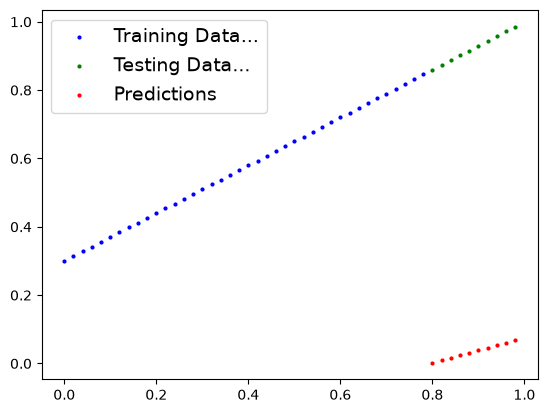

In [19]:
plot_predictions(predictions=y_preds)

In [20]:
# training the model...
# The whole idea of training is for a model to move from some unkown parameters (these may be random ) to some known parameters
# in order word from a poor representation of the data to a better representation of the data

# using a loss function to check hw poor the model is
# loss fn can also be called cost function or criterion in different areas. For our case, we are gonna refer to it as loss function

# --Things we need to train--:
# Loss function: a function to measure how wrong your model's prediction are to the ideal ouputs
# optimizer: Takes into account the loss of a model and adjusts the model's parameters (e.g weight & bias)

# In pytorch we need:
# a training loop
# a testing loop

# check out our model parameters (a parameter is a value that the model set itself)
# hyperparameter -> set by ourselves lr = 0.01

# Setup a loss function

loss_fn = nn.L1Loss()
 

# setup an optimizer (stochastic gradient descent)
# what parameters to learn -> model.parameters() and lr -> learning rate

# Q: Which loss function and optimizer should I use?
# A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular
# problem set.
# For example, for a regression problem (like ours), a loss function of nn.L1Loss() and an optimizer like torch.optim.SGD() will
# suffice.

# But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss function of
# nn.BCELoss() (binary cross entropy loss).


# Building a training loop (and a testing loop) in PyTorch
# A couple of things we need in a training loop:
# 0. Loop through the data
# 1. Forward pass (this involves data moving through our model's forward() functions) to make predictions on data - also called forward
# propagation
# 2. Calculate the loss (compare forward pass predictions to ground truth labels)
# 3. Optimizer zero grad
# 4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to
# the loss (backpropagation)
# 5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (gradient descent)

optimizer = optim.SGD(model.parameters(), lr=0.01) 

# An epoch is one loop through the data... an hyperparameter cuz we set it by ourselve

# there's train() and eval() mode in our model
# train() turn on the require_grad to TRUE
# eval() turn off gradient tracking

# Let's sing the @PyTorch optimization loop song

# It's train time!
# do the forward pass,
# calculate the loss,
# optimizer zero grad,
# losssss backwards!

# Optimizer step step step

# Let's test now!
# with torch no grad:
# do the forward pass,
# calculate the loss,
# watch it go down down down!

epochs = 1000

epoch_count = []
train_loss_values = []
test_loss_values = []




for epoch in range(epochs):
    model.train()
    y_preds = model(x_train)
    loss = loss_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
         test_preds = model(x_test)
         test_loss = loss_fn(test_preds, y_test)

    if epoch % 10 == 0:
       epoch_count.append(epoch)
       train_loss_values.append(loss)
       test_loss_values.append(test_loss)
       print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

print(model.state_dict())









Epoch: 0 | Loss: 0.7182652950286865 | Test loss: 0.8744664192199707
Epoch: 10 | Loss: 0.6030553579330444 | Test loss: 0.7397564649581909
Epoch: 20 | Loss: 0.48784536123275757 | Test loss: 0.6050465703010559
Epoch: 30 | Loss: 0.37263545393943787 | Test loss: 0.4703366160392761
Epoch: 40 | Loss: 0.257425457239151 | Test loss: 0.3356266915798187
Epoch: 50 | Loss: 0.14221547544002533 | Test loss: 0.20091672241687775
Epoch: 60 | Loss: 0.030374601483345032 | Test loss: 0.07090263068675995
Epoch: 70 | Loss: 0.01594698056578636 | Test loss: 0.03711389750242233
Epoch: 80 | Loss: 0.01249538641422987 | Test loss: 0.028154438361525536
Epoch: 90 | Loss: 0.009065224789083004 | Test loss: 0.020568806678056717
Epoch: 100 | Loss: 0.005630563013255596 | Test loss: 0.01229625940322876
Epoch: 110 | Loss: 0.002236152533441782 | Test loss: 0.005433159880340099
Epoch: 120 | Loss: 0.006322450004518032 | Test loss: 0.009400790557265282
Epoch: 130 | Loss: 0.006322450004518032 | Test loss: 0.009400790557265282
E

C:\Users\whizz\AppData\Local\Temp\ipykernel_14956\2727805515.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  plt.plot(epoch_count, torch.tensor(train_loss_values).numpy(), label="Training")


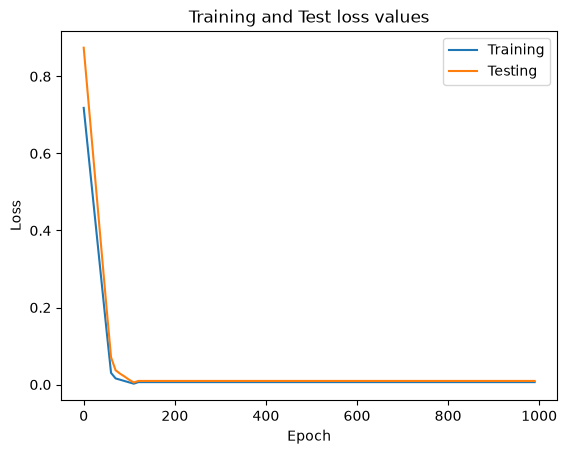

In [21]:

# has to convert the train_loss_values to numpy because
# it what matplot used under the hook, and the train_loss_value is tensor with grad unlike scalar tensor 
# that can just be a original number since inference_mode() will turn off the grad and the tensor will just be oridinary number

plt.plot(epoch_count, torch.tensor(train_loss_values).numpy(), label="Training")
plt.plot(epoch_count, test_loss_values, label="Testing")

plt.title("Training and Test loss values")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


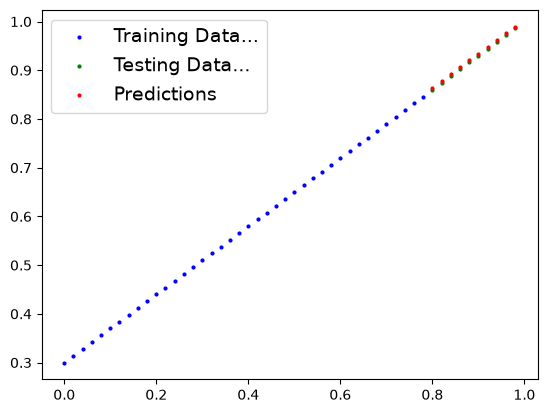

In [22]:
with torch.inference_mode():
    y_preds = model(x_test)
    plot_predictions(predictions=y_preds)
    

In [23]:
# # torch.tensor(train_loss_values).numpy()
# torch.Tensor.numpy(train_loss_values)
train_loss_values
# test_loss_values

[tensor(0.7183, grad_fn=<MeanBackward0>),
 tensor(0.6031, grad_fn=<MeanBackward0>),
 tensor(0.4878, grad_fn=<MeanBackward0>),
 tensor(0.3726, grad_fn=<MeanBackward0>),
 tensor(0.2574, grad_fn=<MeanBackward0>),
 tensor(0.1422, grad_fn=<MeanBackward0>),
 tensor(0.0304, grad_fn=<MeanBackward0>),
 tensor(0.0159, grad_fn=<MeanBackward0>),
 tensor(0.0125, grad_fn=<MeanBackward0>),
 tensor(0.0091, grad_fn=<MeanBackward0>),
 tensor(0.0056, grad_fn=<MeanBackward0>),
 tensor(0.0022, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackward0>),
 tensor(0.0063, grad_fn=<MeanBackw

In [24]:
# saving model

# There are there main method for saving and loading models in pytorch
#  Saving a model in PyTorch

# There are three main methods you should about for saving and loading models in PyTorch.
# 1. torch.save() - allows you save a PyTorch object in Python's pickle format
# 2. torch.load() - allows you load a saved PyTorch object
# 3. torch.nn.Module.load_state_dict() -this allows to load a model's saved state dictionary 


In [25]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "model_one.pth"
SAVE_MODEL_PATH = MODEL_PATH / MODEL_NAME



In [30]:
# saving model

torch.save(obj=model.state_dict(), f=SAVE_MODEL_PATH)


In [33]:
# loading model

loaded_model = LinearRegression()
loaded_model.load_state_dict(torch.load(f=SAVE_MODEL_PATH))

<All keys matched successfully>

In [42]:
loaded_model.state_dict()
loaded_model.eval()
with torch.inference_mode():
   load_preds = loaded_model(x_test)
load_preds, y_test

(tensor([[0.8645],
         [0.8784],
         [0.8923],
         [0.9062],
         [0.9201],
         [0.9340],
         [0.9479],
         [0.9618],
         [0.9758],
         [0.9897]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))